In [1]:
print("Method 3")

Method 3


In [2]:
# to study how cell-cell interactions change between perivascular cells (PVs) and trophoblast cells as 
# the trophoblast differentiate and invade the maternal uterus. 

In [3]:
import os
import zipfile

import pandas as pd
import anndata

pd.set_option('display.max_columns', 100)

BASE_DIR = '/home/tanasa/Desktop/CCI_CellPhoneDB'

In [4]:
# --- Input files ---
# cpdb_file_path      : (mandatory) CellphoneDB database zip file. Already downloaded earlier into cellphonedb-data/.
# meta_file_path      : (mandatory) tsv linking cell barcodes to cluster labels.
# counts_file_path    : (mandatory) normalized (log, not z-scaled) counts, h5ad recommended.
# microenvs_file_path : (optional) restricts interactions to cell types within the same microenvironment.
# All four (meta/counts/microenv/DEGs) ship inside CellphoneDB/notebooks/data_tutorial.zip.

In [5]:
# CellPhone will randomly permute the cluster labels of all cells whitin each microenvironement (microenvs_file_path), 
# 1,000 times (default), to test whether the mean average receptor expression level in a cluster and the average ligand expression level 
# between the interacting clusters is higher than those of the rest cell pairs. 

In [6]:
import os
import pandas as pd
import anndata

pd.set_option('display.max_columns', 100)

In [7]:
BASE_DIR = '/home/tanasa/Desktop/CCI_CellPhoneDB'

cpdb_file_path = os.path.join(BASE_DIR, 'cellphonedb-data', 'cellphonedb.zip')

notebooks_dir = os.path.join(BASE_DIR, 'CellphoneDB', 'notebooks')
data_dir = os.path.join(notebooks_dir, 'data')

meta_file_path = os.path.join(data_dir, 'metadata.tsv')
counts_file_path = os.path.join(data_dir, 'normalised_log_counts.h5ad')
microenvs_file_path = os.path.join(data_dir, 'microenvironment.tsv')

out_path = os.path.join(BASE_DIR, 'results', 'method2_noTF')
os.makedirs(out_path, exist_ok=True)

In [8]:
adata = anndata.read_h5ad(counts_file_path)
adata.shape

(3312, 30800)

In [9]:
# Extract the tutorial data once (data_tutorial.zip -> notebooks/data/*)
if not os.path.exists(meta_file_path):
    with zipfile.ZipFile(tutorial_zip) as zf:
        zf.extractall(notebooks_dir)
    print(f'Extracted {tutorial_zip} -> {data_dir}')
else:
    print('Tutorial data already extracted.')

Tutorial data already extracted.


In [10]:
assert os.path.exists(cpdb_file_path), f'Missing database zip: {cpdb_file_path}'
assert os.path.exists(meta_file_path), f'Missing meta file: {meta_file_path}'
assert os.path.exists(counts_file_path), f'Missing counts file: {counts_file_path}'
assert os.path.exists(microenvs_file_path), f'Missing microenvironment file: {microenvs_file_path}'

In [11]:
# The metadata file is compossed of two columns:

# barcode_sample: this column indicates the barcode of each cell in the experiment.
# cell_type: this column denotes the cell label assigned.

metadata = pd.read_csv(meta_file_path, sep='\t')
metadata.head(3)

,barcode_sample,cell_type
0,AGCGATTAGTCTAACC-1_Pla_HDBR10917733,B_cells
1,ATCCGTGAGGCTAGAA-1_Pla_Camb10714918,B_cells
2,AGTAACCCATTAAAGG-1_Pla_HDBR10917733,B_cells


In [12]:
adata = anndata.read_h5ad(counts_file_path)
adata.shape

(3312, 30800)

In [13]:
# Barcodes in metadata and counts must match (order-insensitive check)
sorted(adata.obs.index) == sorted(metadata['barcode_sample'])

True

In [14]:
# 3) Micronevironments defines the cell types that belong to a a given microenvironment. 
# CellphoneDB will only calculate interactions between cells that belong to a given microenvironment

microenv = pd.read_csv(microenvs_file_path, sep='\t')
microenv.head(3)

microenv.groupby('microenvironment', group_keys=False)['cell_type'] \
    .apply(lambda x: list(x.value_counts().index))

microenvironment
Env1    [PV MMP11, PV MYH11, PV STEAP4, EVT_1, EVT_2, ...
Name: cell_type, dtype: object

In [15]:
microenv.groupby('microenvironment', group_keys = False)['cell_type'].apply(lambda x : list(x.value_counts().index))

microenvironment
Env1    [PV MMP11, PV MYH11, PV STEAP4, EVT_1, EVT_2, ...
Name: cell_type, dtype: object

In [16]:
# 4) Differentially expressed genes file s is a two columns file indicanting which gene up-regulated (or specific) 
# in a cell type. The first column corresponds to the cluster name (these match with those in the metadata file) 
# and the second column the up-regulated gene.

In [17]:
print("""Run CellphoneDB with differential analysis (method 3)""")
# The output of this method will be saved in output_path and also returned to the predefined variables.

Run CellphoneDB with differential analysis (method 3)


In [18]:
import os

BASE_DIR = '/home/tanasa/Desktop/CCI_CellPhoneDB'
notebooks_dir = os.path.join(BASE_DIR, 'CellphoneDB', 'notebooks')
data_dir = os.path.join(notebooks_dir, 'data')

cpdb_file_path = os.path.join(BASE_DIR, 'cellphonedb-data', 'cellphonedb.zip')
meta_file_path = os.path.join(data_dir, 'metadata.tsv')
counts_file_path = os.path.join(data_dir, 'normalised_log_counts.h5ad')
microenvs_file_path = os.path.join(data_dir, 'microenvironment.tsv')
active_tf_path = os.path.join(data_dir, 'active_TFs.tsv')
degs_file_path = os.path.join(data_dir, 'DEGs_inv_trophoblast.tsv')   # <- this is the one that was missing

out_path = os.path.join(BASE_DIR, 'results', 'method3_withScore')
os.makedirs(out_path, exist_ok=True)

for p in (cpdb_file_path, meta_file_path, counts_file_path, microenvs_file_path, active_tf_path, degs_file_path):
    assert os.path.exists(p), f'Missing input file: {p}'


In [19]:
# CellphoneDB employs a geometric sketching procedure (Hie et al. 2019) to preserve the structure of the data without 
# losing information from lowly represented cells. For this tutorial, we have opted to manually downsample the count 
# matrix and the metadata file accordingly.

In [20]:
# Here's CellphoneDB/notebooks/data/DEGs_inv_trophoblast.tsv — 13,809 rows (+ header), covering the trophoblast differentiation lineage:

# cluster  gene      logFC    P.Value        adj.P.Val
# GC       BGN       1.605    3.95e-131      4.84e-127
# GC       HLA-G     1.413    5.62e-254      6.89e-250
# GC       B2M       1.359    0.0            0.0
# GC       TMSB10    1.318    0.0            0.0
# GC       AOC1      1.191    2.66e-33       3.26e-29
# GC       PSAP      1.119    8.26e-254      1.01e-249
# GC       CTSL      1.061    3.50e-268      4.30e-264
# GC       PRSS8     1.003    1.85e-225      2.26e-221
# GC       SERPINE2  0.985    2.55e-135      3.13e-131
# GC       HTRA1     0.969    1.40e-104      1.71e-100

In [21]:
# degs_file_path	New/mandatory for Method 3. The DEG file we discussed — two columns (cluster, gene), 
# listing which genes are markers for which cell type. 

# This is what makes Method 3 "differential-expression-based" rather than purely expression-based.

In [22]:
from cellphonedb.src.core.methods import cpdb_degs_analysis_method

cpdb_results = cpdb_degs_analysis_method.call(
    cpdb_file_path = cpdb_file_path,                            # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_file_path,                            # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_file_path,                        # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    degs_file_path = degs_file_path,                            # mandatory: tsv file with DEG to account.
    counts_data = 'hgnc_symbol',                                # defines the gene annotation in counts matrix.
    active_tfs_file_path = active_tf_path,                      # optional: defines cell types and their active TFs.
    microenvs_file_path = microenvs_file_path,                  # optional (default: None): defines cells per microenvironment.
    score_interactions = True,                                  # optional: whether to score interactions or not. 
    threshold = 0.1,                                            # defines the min % of cells expressing a gene for this to be employed in the analysis.
    result_precision = 3,                                       # Sets the rounding for the mean values in significan_means.
    separator = '|',                                            # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    debug = False,                                              # Saves all intermediate tables emplyed during the analysis in pkl format.
    output_path = out_path,                                     # Path to save results
    output_suffix = None,                                       # Replaces the timestamp in the output files by a user defined string in the  (default: None)
    threads = 25
    )

[ ][CORE][22/07/26-23:48:52][INFO] [Cluster DEGs Analysis] Threshold:0.1 Precision:3
Reading user files...
The following user files were loaded successfully:
/home/tanasa/Desktop/CCI_CellPhoneDB/CellphoneDB/notebooks/data/normalised_log_counts.h5ad
/home/tanasa/Desktop/CCI_CellPhoneDB/CellphoneDB/notebooks/data/metadata.tsv
/home/tanasa/Desktop/CCI_CellPhoneDB/CellphoneDB/notebooks/data/microenvironment.tsv
/home/tanasa/Desktop/CCI_CellPhoneDB/CellphoneDB/notebooks/data/active_TFs.tsv
/home/tanasa/Desktop/CCI_CellPhoneDB/CellphoneDB/notebooks/data/DEGs_inv_trophoblast.tsv


/home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages/cellphonedb/src/core/models/complex/complex_helper.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  complex_to_protein_ids = complex_composition.groupby(COMPLEX_ID).apply(lambda x: x[PROTEIN_ID].values).to_dict()


[ ][CORE][22/07/26-23:48:53][INFO] Running Real Analysis
[ ][CORE][22/07/26-23:48:53][INFO] Limiting cluster combinations using microenvironments
[ ][CORE][22/07/26-23:48:53][INFO] Running DEGs-based Analysis
[ ][CORE][22/07/26-23:48:53][INFO] Building results


/home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages/cellphonedb/src/core/methods/cpdb_degs_analysis_method.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  complexes = complex_composition.groupby(COMPLEX_ID).apply(lambda x: x[PROTEIN_ID].values).to_dict()


[ ][CORE][22/07/26-23:48:54][INFO] Scoring interactions: Filtering genes per cell type..


...

[ ][CORE][22/07/26-23:48:54][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|████████████████████████████████████████████████████████████| 42/42 [00:00<00:00, 1870.41it/s]
/home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages/cellphonedb/utils/scoring_utils.py:138: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matrix[index_name].replace(to_replace=id2name, inplace=True)


[ ][CORE][22/07/26-23:48:55][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████████████████████████████████████████████████████████| 81/81 [00:05<00:00, 13.86it/s]


Saved deconvoluted to /home/tanasa/Desktop/CCI_CellPhoneDB/results/method3_withScore/degs_analysis_deconvoluted_07_22_2026_234901.txt
Saved deconvoluted_percents to /home/tanasa/Desktop/CCI_CellPhoneDB/results/method3_withScore/degs_analysis_deconvoluted_percents_07_22_2026_234901.txt
Saved means to /home/tanasa/Desktop/CCI_CellPhoneDB/results/method3_withScore/degs_analysis_means_07_22_2026_234901.txt
Saved relevant_interactions to /home/tanasa/Desktop/CCI_CellPhoneDB/results/method3_withScore/degs_analysis_relevant_interactions_07_22_2026_234901.txt
Saved significant_means to /home/tanasa/Desktop/CCI_CellPhoneDB/results/method3_withScore/degs_analysis_significant_means_07_22_2026_234901.txt
Saved CellSign_active_interactions to /home/tanasa/Desktop/CCI_CellPhoneDB/results/method3_withScore/degs_analysis_CellSign_active_interactions_07_22_2026_234901.txt
Saved CellSign_active_interactions_deconvoluted to /home/tanasa/Desktop/CCI_CellPhoneDB/results/method3_withScore/degs_analysis_Cell

In [23]:
# The DEGs here are computed per cell type (cluster), not between conditions — a one-vs-rest marker-gene test (Seurat's FindAllMarkers), 
# not disease-vs-control.

# cluster = one of the 6 trophoblast differentiation states (GC, eEVT, iEVT, EVT_1, EVT_2, VCT_CCC).

# A gene counts as "DE" if it's significantly up-regulated in that cluster vs. all other cells (p_val_adj < 0.05, avg_log2FC > 0.1).
# Method 3 then flags an interaction as relevant if at least one gene is a marker for one of the two cell types in the pair — 
# testing whether trophoblast identity relates to cell-cell signaling, not a treatment/condition effect.
# A condition-based version is technically possible (CellphoneDB just reads column 1 as a label, 
# column 2 as gene — you could name clusters EVT_1_disease vs EVT_1_control), but that's not what this tutorial does.

In [24]:
print(""" Silent notes about the comparisons between NORMAL and DISEASE""")

# There are two common ways to do it, depending on what question you actually want answered:

# Approach A — Compare CCI results across conditions (most common)
# Run CellphoneDB separately for each condition, then compare the output tables (means, interaction scores) between runs. 
# This tells you "does this interaction exist/change in strength between disease and control," 
# using the normal per-cell-type Methods 1 or 2 — no DEG file needed at all.

 Silent notes about the comparisons between NORMAL and DISEASE


In [25]:
# Approach B — Fold condition into Method 3's DEG file directly

# If you specifically want CellphoneDB's DEG-based filtering (Method 3) to be condition-aware in one run, 
# you compute DEGs as condition-vs-condition within each cell type (not cluster-vs-rest), 
# and combine cell_type and condition into your cluster labels.

# In your metadata, combine cell type and condition into one label
# metadata['cluster'] = metadata['cell_type'] + '_' + metadata['condition']
# e.g. "EVT_1_disease", "EVT_1_control", "GC_disease", "GC_control", ...
# Then compute DEGs per cell type, disease vs. control (not one-vs-rest), e.g. with scanpy:

# import scanpy as sc

# degs_rows = []
# for ct in adata.obs['cell_type'].unique():
#    sub = adata[adata.obs['cell_type'] == ct].copy()
#    sc.tl.rank_genes_groups(sub, groupby='condition', groups=['disease'], reference='control', method='wilcoxon')
#    res = sc.get.rank_genes_groups_df(sub, group='disease')
#    res = res[(res['pvals_adj'] < 0.05) & (res['logfoldchanges'] > 0.1)]
#    res['cluster'] = f'{ct}_disease'   # matches your metadata['cluster'] labels
#    degs_rows.append(res[['cluster', 'names']].rename(columns={'names': 'gene'}))

# degs_df = pd.concat(degs_rows)
# degs_df.to_csv('data/DEGs_disease_vs_control.tsv', sep='\t', index=False)

In [26]:
list(cpdb_results.keys())

['deconvoluted',
 'deconvoluted_percents',
 'means',
 'relevant_interactions',
 'significant_means',
 'CellSign_active_interactions',
 'CellSign_active_interactions_deconvoluted',
 'interaction_scores']

In [27]:
cpdb_results['relevant_interactions'].head(2)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,PV MMP11|EVT_1,PV MMP11|EVT_2,PV MMP11|iEVT,PV MMP11|VCT_CCC,PV MMP11|GC,PV MMP11|eEVT,PV MYH11|EVT_1,PV MYH11|EVT_2,PV MYH11|iEVT,PV MYH11|VCT_CCC,PV MYH11|GC,PV MYH11|eEVT,PV STEAP4|EVT_1,PV STEAP4|EVT_2,PV STEAP4|iEVT,PV STEAP4|VCT_CCC,PV STEAP4|GC,PV STEAP4|eEVT,EVT_1|PV MMP11,EVT_1|PV MYH11,EVT_1|PV STEAP4,EVT_1|EVT_1,EVT_1|EVT_2,EVT_1|iEVT,EVT_1|VCT_CCC,EVT_1|GC,EVT_1|eEVT,EVT_2|PV MMP11,EVT_2|PV MYH11,EVT_2|PV STEAP4,EVT_2|EVT_1,EVT_2|EVT_2,EVT_2|iEVT,EVT_2|VCT_CCC,EVT_2|GC,EVT_2|eEVT,iEVT|PV MMP11,iEVT|PV MYH11,iEVT|PV STEAP4,iEVT|EVT_1,iEVT|EVT_2,iEVT|iEVT,iEVT|VCT_CCC,iEVT|GC,iEVT|eEVT,VCT_CCC|PV MMP11,VCT_CCC|PV MYH11,VCT_CCC|PV STEAP4,VCT_CCC|EVT_1,VCT_CCC|EVT_2,VCT_CCC|iEVT,VCT_CCC|VCT_CCC,VCT_CCC|GC,VCT_CCC|eEVT,GC|PV MMP11,GC|PV MYH11,GC|PV STEAP4,GC|EVT_1,GC|EVT_2,GC|iEVT,GC|VCT_CCC,GC|GC,GC|eEVT,eEVT|PV MMP11,eEVT|PV MYH11,eEVT|PV STEAP4,eEVT|EVT_1,eEVT|EVT_2,eEVT|iEVT,eEVT|VCT_CCC,eEVT|GC,eEVT|eEVT
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,True,Adhesion-Adhesion,Adhesion by Cadherin,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
2,CPI-SC0C8B7BCBB,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [28]:
cpdb_results['significant_means'].head(2)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,rank,PV MMP11|PV MMP11,PV MMP11|PV MYH11,PV MMP11|PV STEAP4,PV MMP11|EVT_1,PV MMP11|EVT_2,PV MMP11|iEVT,PV MMP11|VCT_CCC,PV MMP11|GC,PV MMP11|eEVT,PV MYH11|PV MMP11,PV MYH11|PV MYH11,PV MYH11|PV STEAP4,PV MYH11|EVT_1,PV MYH11|EVT_2,PV MYH11|iEVT,PV MYH11|VCT_CCC,PV MYH11|GC,PV MYH11|eEVT,PV STEAP4|PV MMP11,PV STEAP4|PV MYH11,PV STEAP4|PV STEAP4,PV STEAP4|EVT_1,PV STEAP4|EVT_2,PV STEAP4|iEVT,PV STEAP4|VCT_CCC,PV STEAP4|GC,PV STEAP4|eEVT,EVT_1|PV MMP11,EVT_1|PV MYH11,EVT_1|PV STEAP4,EVT_1|EVT_1,EVT_1|EVT_2,EVT_1|iEVT,EVT_1|VCT_CCC,EVT_1|GC,EVT_1|eEVT,EVT_2|PV MMP11,EVT_2|PV MYH11,EVT_2|PV STEAP4,EVT_2|EVT_1,EVT_2|EVT_2,EVT_2|iEVT,EVT_2|VCT_CCC,EVT_2|GC,EVT_2|eEVT,iEVT|PV MMP11,iEVT|PV MYH11,iEVT|PV STEAP4,iEVT|EVT_1,iEVT|EVT_2,iEVT|iEVT,iEVT|VCT_CCC,iEVT|GC,iEVT|eEVT,VCT_CCC|PV MMP11,VCT_CCC|PV MYH11,VCT_CCC|PV STEAP4,VCT_CCC|EVT_1,VCT_CCC|EVT_2,VCT_CCC|iEVT,VCT_CCC|VCT_CCC,VCT_CCC|GC,VCT_CCC|eEVT,GC|PV MMP11,GC|PV MYH11,GC|PV STEAP4,GC|EVT_1,GC|EVT_2,GC|iEVT,GC|VCT_CCC,GC|GC,GC|eEVT,eEVT|PV MMP11,eEVT|PV MYH11,eEVT|PV STEAP4,eEVT|EVT_1,eEVT|EVT_2,eEVT|iEVT,eEVT|VCT_CCC,eEVT|GC,eEVT|eEVT
17,CPI-SC088A27EA5,COL24A1_integrin_a2b1_complex,simple:Q17RW2,complex:integrin_a2b1_complex,COL24A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,0.012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.297
2620,CPI-SC02D16C89A,WNT2B_FZD6_LRP5,simple:Q93097,complex:FZD6_LRP5,WNT2B,NaN,True,False,False,curated,False,Ligand-Receptor,Signaling by WNT,0.012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
cpdb_results['means'].head(2)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,PV MMP11|PV MMP11,PV MMP11|PV MYH11,PV MMP11|PV STEAP4,PV MMP11|EVT_1,PV MMP11|EVT_2,PV MMP11|iEVT,PV MMP11|VCT_CCC,PV MMP11|GC,PV MMP11|eEVT,PV MYH11|PV MMP11,PV MYH11|PV MYH11,PV MYH11|PV STEAP4,PV MYH11|EVT_1,PV MYH11|EVT_2,PV MYH11|iEVT,PV MYH11|VCT_CCC,PV MYH11|GC,PV MYH11|eEVT,PV STEAP4|PV MMP11,PV STEAP4|PV MYH11,PV STEAP4|PV STEAP4,PV STEAP4|EVT_1,PV STEAP4|EVT_2,PV STEAP4|iEVT,PV STEAP4|VCT_CCC,PV STEAP4|GC,PV STEAP4|eEVT,EVT_1|PV MMP11,EVT_1|PV MYH11,EVT_1|PV STEAP4,EVT_1|EVT_1,EVT_1|EVT_2,EVT_1|iEVT,EVT_1|VCT_CCC,EVT_1|GC,EVT_1|eEVT,EVT_2|PV MMP11,EVT_2|PV MYH11,EVT_2|PV STEAP4,EVT_2|EVT_1,EVT_2|EVT_2,EVT_2|iEVT,EVT_2|VCT_CCC,EVT_2|GC,EVT_2|eEVT,iEVT|PV MMP11,iEVT|PV MYH11,iEVT|PV STEAP4,iEVT|EVT_1,iEVT|EVT_2,iEVT|iEVT,iEVT|VCT_CCC,iEVT|GC,iEVT|eEVT,VCT_CCC|PV MMP11,VCT_CCC|PV MYH11,VCT_CCC|PV STEAP4,VCT_CCC|EVT_1,VCT_CCC|EVT_2,VCT_CCC|iEVT,VCT_CCC|VCT_CCC,VCT_CCC|GC,VCT_CCC|eEVT,GC|PV MMP11,GC|PV MYH11,GC|PV STEAP4,GC|EVT_1,GC|EVT_2,GC|iEVT,GC|VCT_CCC,GC|GC,GC|eEVT,eEVT|PV MMP11,eEVT|PV MYH11,eEVT|PV STEAP4,eEVT|EVT_1,eEVT|EVT_2,eEVT|iEVT,eEVT|VCT_CCC,eEVT|GC,eEVT|eEVT
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,True,Adhesion-Adhesion,Adhesion by Cadherin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.105,0.0,0.0,0.071,0.099,0.089,0.077,0.099,0.346,0.077,0.0,0.0,0.043,0.071,0.060,0.048,0.070,0.317,0.131,0.0,0.0,0.097,0.125,0.115,0.102,0.124,0.371,0.194,0.0,0.0,0.160,0.188,0.177,0.165,0.187,0.434,0.321,0.0,0.0,0.287,0.315,0.305,0.292,0.314,0.561,0.193,0.0,0.0,0.159,0.187,0.177,0.164,0.186,0.433,0.232,0.0,0.0,0.198,0.225,0.215,0.203,0.225,0.472
1,CPI-SC0B5CEA47D,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.041,0.0,0.0,0.006,0.034,0.024,0.012,0.034,0.281,0.000,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.043,0.0,0.0,0.009,0.037,0.026,0.014,0.036,0.283,0.042,0.0,0.0,0.007,0.035,0.025,0.013,0.035,0.282,0.000,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.049,0.0,0.0,0.015,0.043,0.032,0.020,0.042,0.289


In [30]:
cpdb_results['interaction_scores'].head()

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,PV MMP11|PV MMP11,PV MMP11|PV MYH11,PV MMP11|PV STEAP4,PV MMP11|EVT_1,PV MMP11|EVT_2,PV MMP11|iEVT,PV MMP11|VCT_CCC,PV MMP11|GC,PV MMP11|eEVT,PV MYH11|PV MMP11,PV MYH11|PV MYH11,PV MYH11|PV STEAP4,PV MYH11|EVT_1,PV MYH11|EVT_2,PV MYH11|iEVT,PV MYH11|VCT_CCC,PV MYH11|GC,PV MYH11|eEVT,PV STEAP4|PV MMP11,PV STEAP4|PV MYH11,PV STEAP4|PV STEAP4,PV STEAP4|EVT_1,PV STEAP4|EVT_2,PV STEAP4|iEVT,PV STEAP4|VCT_CCC,PV STEAP4|GC,PV STEAP4|eEVT,EVT_1|PV MMP11,EVT_1|PV MYH11,EVT_1|PV STEAP4,EVT_1|EVT_1,EVT_1|EVT_2,EVT_1|iEVT,EVT_1|VCT_CCC,EVT_1|GC,EVT_1|eEVT,EVT_2|PV MMP11,EVT_2|PV MYH11,EVT_2|PV STEAP4,EVT_2|EVT_1,EVT_2|EVT_2,EVT_2|iEVT,EVT_2|VCT_CCC,EVT_2|GC,EVT_2|eEVT,iEVT|PV MMP11,iEVT|PV MYH11,iEVT|PV STEAP4,iEVT|EVT_1,iEVT|EVT_2,iEVT|iEVT,iEVT|VCT_CCC,iEVT|GC,iEVT|eEVT,VCT_CCC|PV MMP11,VCT_CCC|PV MYH11,VCT_CCC|PV STEAP4,VCT_CCC|EVT_1,VCT_CCC|EVT_2,VCT_CCC|iEVT,VCT_CCC|VCT_CCC,VCT_CCC|GC,VCT_CCC|eEVT,GC|PV MMP11,GC|PV MYH11,GC|PV STEAP4,GC|EVT_1,GC|EVT_2,GC|iEVT,GC|VCT_CCC,GC|GC,GC|eEVT,eEVT|PV MMP11,eEVT|PV MYH11,eEVT|PV STEAP4,eEVT|EVT_1,eEVT|EVT_2,eEVT|iEVT,eEVT|VCT_CCC,eEVT|GC,eEVT|eEVT
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,True,Adhesion-Adhesion,Adhesion by Cadherin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.095,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.533,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74.911,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,51.391
1,CPI-SC0B5CEA47D,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2,CPI-SC0C8B7BCBB,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34.588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
3,CPI-SC0D3C12C3F,COL11A2_integrin_a2b1_complex,simple:P13942,complex:integrin_a2b1_complex,COL11A2,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
4,CPI-SC0B86B7CED,COL12A1_integrin_a2b1_complex,simple:Q99715,complex:integrin_a2b1_complex,COL12A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.37,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43.348,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000


In [31]:
cpdb_results['deconvoluted'].head(2)

,gene_name,uniprot,is_complex,protein_name,complex_name,id_cp_interaction,gene,B_cells,DC,EVT_1,EVT_2,Endo_F,Endo_L,Endo_M,GC,Granulocytes,HOFB,ILC3,M3,MO,NK,PV MMP11,PV MYH11,PV STEAP4,Plasma,SCT,T_cells,VCT,VCT_CCC,VCT_fusing,VCT_p,dDC,dEpi_lumenal,dEpi_secretory,dM1,dM2,dNK1,dNK2,dNK3,dS1,dS2,dS3,dT_cells,dT_regs,eEVT,fF1,fF2,iEVT,uSMC
multidata_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1355,UBASH3B,Q8TF42,True,UBS3B_HUMAN,Dehydroepiandrosterone_bySTS,CPI-CS09B8977D7,UBASH3B,0.24,0.0,0.621,1.06,0.105,0.212,0.216,1.424,0.0,0.411,0.25,0.465,0.068,0.127,0.114,0.0,0.0,0.0,0.161,0.0,0.484,0.576,0.158,0.454,0.608,0.0,0.124,0.24,0.36,1.134,0.632,0.437,0.118,0.224,0.162,0.025,0.124,1.182,0.055,0.0,1.402,0.338
1355,UBASH3B,Q8TF42,True,UBS3B_HUMAN,Dehydroepiandrosterone_bySTS,CPI-CS05760BB78,UBASH3B,0.24,0.0,0.621,1.06,0.105,0.212,0.216,1.424,0.0,0.411,0.25,0.465,0.068,0.127,0.114,0.0,0.0,0.0,0.161,0.0,0.484,0.576,0.158,0.454,0.608,0.0,0.124,0.24,0.36,1.134,0.632,0.437,0.118,0.224,0.162,0.025,0.124,1.182,0.055,0.0,1.402,0.338


In [32]:
cpdb_results['CellSign_active_interactions'].head(2)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,PV MMP11|EVT_1,PV MMP11|EVT_2,PV MMP11|iEVT,PV MMP11|VCT_CCC,PV MMP11|GC,PV MMP11|eEVT,PV MYH11|EVT_1,PV MYH11|EVT_2,PV MYH11|iEVT,PV MYH11|VCT_CCC,PV MYH11|GC,PV MYH11|eEVT,PV STEAP4|EVT_1,PV STEAP4|EVT_2,PV STEAP4|iEVT,PV STEAP4|VCT_CCC,PV STEAP4|GC,PV STEAP4|eEVT,EVT_1|PV MMP11,EVT_1|PV MYH11,EVT_1|PV STEAP4,EVT_1|EVT_1,EVT_1|EVT_2,EVT_1|iEVT,EVT_1|VCT_CCC,EVT_1|GC,EVT_1|eEVT,EVT_2|PV MMP11,EVT_2|PV MYH11,EVT_2|PV STEAP4,EVT_2|EVT_1,EVT_2|EVT_2,EVT_2|iEVT,EVT_2|VCT_CCC,EVT_2|GC,EVT_2|eEVT,iEVT|PV MMP11,iEVT|PV MYH11,iEVT|PV STEAP4,iEVT|EVT_1,iEVT|EVT_2,iEVT|iEVT,iEVT|VCT_CCC,iEVT|GC,iEVT|eEVT,VCT_CCC|PV MMP11,VCT_CCC|PV MYH11,VCT_CCC|PV STEAP4,VCT_CCC|EVT_1,VCT_CCC|EVT_2,VCT_CCC|iEVT,VCT_CCC|VCT_CCC,VCT_CCC|GC,VCT_CCC|eEVT,GC|PV MMP11,GC|PV MYH11,GC|PV STEAP4,GC|EVT_1,GC|EVT_2,GC|iEVT,GC|VCT_CCC,GC|GC,GC|eEVT,eEVT|PV MMP11,eEVT|PV MYH11,eEVT|PV STEAP4,eEVT|EVT_1,eEVT|EVT_2,eEVT|iEVT,eEVT|VCT_CCC,eEVT|GC,eEVT|eEVT
0,CPI-SS0A28DCA72,CXCL12_CXCR4,simple:P48061,simple:P61073,CXCL12,CXCR4,True,False,True,curated,False,Ligand-Receptor,Signaling by Chemokines,1,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0
1,CPI-SS0CC966B71,BTC_EGFR,simple:P35070,simple:P00533,BTC,EGFR,True,False,True,curated,False,Ligand-Receptor,Signaling by Epidermal growth factor,1,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0


In [33]:
print("""Explore CellphoneDB results""")

Explore CellphoneDB results


In [34]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['EVT_1', 'EVT_2', 'GC', 'eEVT', 'iEVT'],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = ['PV MMP11', 'PV MYH11', 'PV STEAP4'],     # List of cells 2, will be paired to cells 1 (list or 'All').
    query_genes = ['TGFBR1'],                                       # filter interactions based on the genes participating (list).
    query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
    query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(3)

,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean
1,CSF1_CSF1R,simple:P09603,simple:P07333,CSF1,CSF1R,Ligand-Receptor,Signaling by Colony-Stimulating factor,PV MMP11|EVT_1,0.187
2,TGFB3_TGFbeta_receptor2,simple:P10600,complex:TGFbeta_receptor2,TGFB3,NaN,Ligand-Receptor,Signaling by Transforming growth factor,PV MMP11|EVT_1,0.220
6,TGFB3_TGFbeta_receptor1,simple:P10600,complex:TGFbeta_receptor1,TGFB3,NaN,Ligand-Receptor,Signaling by Transforming growth factor,PV MMP11|EVT_1,0.249


In [35]:
print("Visualization")

Visualization


In [36]:
# -- Get annotation columns and interactions 
annotation = list(cpdb_results['relevant_interactions'].columns[:13])
interaction = list(cpdb_results['relevant_interactions'].columns[13:])


# -- Convert relevant_interactions file from wide to long
relevant_interactions_long = pd.melt(cpdb_results['relevant_interactions'],
                                     id_vars = annotation,
                                     var_name = 'Interacting_cell',
                                     value_vars = interaction,
                                     value_name = 'Relevance')

relevant_interactions_long[['Cell_a', 'Cell_b']] = relevant_interactions_long['Interacting_cell'] \
    .str.split('|', expand = True) \
    .rename(columns={0 : 'Cell_a', 1: 'Cell_b'})

relevant_interactions_long.head(3)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,Interacting_cell,Relevance,Cell_a,Cell_b
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,True,Adhesion-Adhesion,Adhesion by Cadherin,PV MMP11|EVT_1,0,PV MMP11,EVT_1
1,CPI-SC0C8B7BCBB,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,PV MMP11|EVT_1,0,PV MMP11,EVT_1
2,CPI-SC0B86B7CED,COL12A1_integrin_a2b1_complex,simple:Q99715,complex:integrin_a2b1_complex,COL12A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,PV MMP11|EVT_1,0,PV MMP11,EVT_1


In [37]:
# -- Convert means file from wide to long
means_long = pd.melt(cpdb_results['means'],
                     id_vars = annotation,
                     var_name = 'Interacting_cell',
                     value_vars = interaction,
                     value_name = 'Mean')

means_long.head(3)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,Interacting_cell,Mean
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,True,Adhesion-Adhesion,Adhesion by Cadherin,PV MMP11|EVT_1,0.0
1,CPI-SC0B5CEA47D,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,PV MMP11|EVT_1,0.0
2,CPI-SC0C8B7BCBB,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Collagen/Integrin,PV MMP11|EVT_1,0.0


In [38]:
print("""Sort interaction by recurrence""")

# To facilitate the selection of interactions of interest we will calculate the recurrence of each interaction 
# (i.e. number of times an interaction appears as relevant across all interacting partners).

Sort interaction by recurrence


In [39]:
print("""
RECURRENCE measures how many different cell-type pairs a given interaction was flagged as relevant in — 
it's a global count per interaction, not per row.
""")


RECURRENCE measures how many different cell-type pairs a given interaction was flagged as relevant in — 
it's a global count per interaction, not per row.



In [40]:
# -- Create a dictionary with recurrence of relevance of any give interaction
id_cp_dict = relevant_interactions_long.groupby('id_cp_interaction')['Relevance'] \
    .sum() \
    .to_dict()

# -- Add new column to indicante the recurrence of an interaction
relevant_interactions_long['Recurrence'] = relevant_interactions_long['id_cp_interaction'] \
    .map(id_cp_dict)

# -- Sort according to the recurrence
relevant_interactions_long = relevant_interactions_long.sort_values(['Recurrence'],
                                                                    ascending = True)

relevant_interactions_long.head(3)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,Interacting_cell,Relevance,Cell_a,Cell_b,Recurrence
30136,CPI-SC04CBB7552,WNT6_FZD6_LRP5,simple:Q9Y6F9,complex:FZD6_LRP5,WNT6,NaN,True,False,False,curated,False,Ligand-Receptor,Signaling by WNT,eEVT|eEVT,0,eEVT,eEVT,1
30137,CPI-SC0DFEAE26D,WNT7A_FZD6_LRP5,simple:O00755,complex:FZD6_LRP5,WNT7A,NaN,True,False,False,curated,False,Ligand-Receptor,Signaling by WNT,eEVT|eEVT,0,eEVT,eEVT,1
30141,CPI-SC063E27411,WNT2B_FZD7_LRP6,simple:Q93097,complex:FZD7_LRP6,WNT2B,NaN,True,False,False,curated,False,Ligand-Receptor,Signaling by WNT,eEVT|eEVT,0,eEVT,eEVT,1


In [41]:
interactions_to_plot = ['CPI-SC0F36DD437', 'CPI-SC06C3BA86F', 'CPI-SS0AB1F04A0', 'CPI-SC051FC855D', 'CPI-SC0DABCC4B5']

idx = [ id in interactions_to_plot for id in relevant_interactions_long['id_cp_interaction'] ]
relevant_interactions_plot = relevant_interactions_long[idx].copy()

In [42]:
from scipy.stats import zscore

# -- Add mean value of the interacting partners
relevant_interactions_plot = relevant_interactions_plot.merge(means_long[['id_cp_interaction', 'Interacting_cell', 'Mean']],
                                                              on = ['id_cp_interaction', 'Interacting_cell'],
                                                              how = 'inner')

In [43]:
# before applying the z-scale normalization we will remove interactions in which both partners are trophoblasts

In [44]:
import itertools

list_trophoblast = ['EVT_1', 'EVT_2', 'GC', 'VCT_CCC', 'eEVT', 'iEVT']
interact_rm = [ '|'.join(i) for i in itertools.product(list_trophoblast, repeat = 2) ]

# -- Interactions to keep
idx_keep = [ i not in interact_rm for i in relevant_interactions_plot['Interacting_cell'] ]
relevant_interactions_plot = relevant_interactions_plot[idx_keep]

In [45]:
# -- Scale within interaction

relevant_interactions_plot['Mean_scaled'] = relevant_interactions_plot.groupby('id_cp_interaction', group_keys = False)['Mean'].transform(lambda x : zscore(x, ddof = 1))
relevant_interactions_plot = relevant_interactions_plot.sort_values('Interacting_cell')

relevant_interactions_plot.head(3)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,Interacting_cell,Relevance,Cell_a,Cell_b,Recurrence,Mean,Mean_scaled
172,CPI-SC0F36DD437,TGFB2_TGFbeta_receptor2,simple:P61812,complex:TGFbeta_receptor2,TGFB2,NaN,True,False,True,curated,False,Ligand-Receptor,Signaling by Transforming growth factor,EVT_1|PV MMP11,1,EVT_1,PV MMP11,25,0.115,-0.013711
271,CPI-SC0DABCC4B5,TGFB1_TGFbeta_receptor1,simple:P01137,complex:TGFbeta_receptor1,TGFB1,NaN,True,False,True,curated,False,Ligand-Receptor,Signaling by Transforming growth factor,EVT_1|PV MMP11,1,EVT_1,PV MMP11,42,0.512,1.449309
347,CPI-SC06C3BA86F,FN1_integrin_a5b1_complex,simple:P02751,complex:integrin_a5b1_complex,FN1,NaN,True,False,False,curated,True,Adhesion-Adhesion,Adhesion by Fibronectin,EVT_1|PV MMP11,1,EVT_1,PV MMP11,64,1.149,-0.140185


In [46]:
# Dot plot of the selected candidates

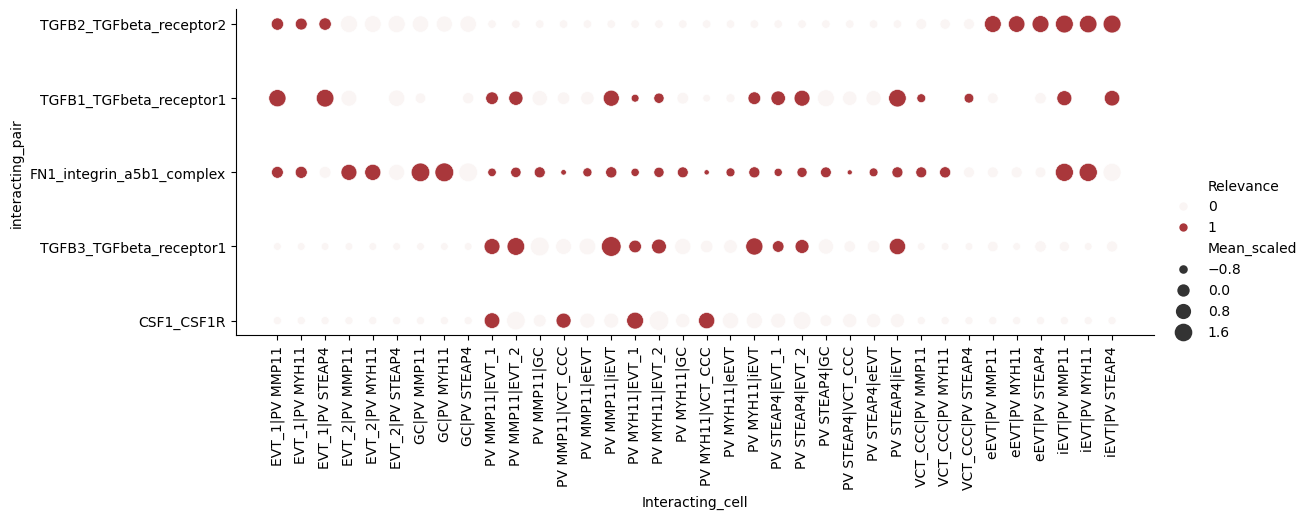

In [47]:
import seaborn as sns

g = sns.relplot(
    data = relevant_interactions_plot,
    x = "Interacting_cell",
    y = "interacting_pair",
    hue = "Relevance",
    size = "Mean_scaled",
    palette = "vlag",
    hue_norm=(-1, 1),
    height = 4,
    aspect = 3,
    sizes = (0, 200)
)
g.set_xticklabels(rotation = 90)

In [48]:
# Kelvin's implementations (kt-plots tutorial) to display CellphoneDB outputs

In [49]:
import os
import anndata as ad
import pandas as pd
import ktplotspy as kpy
import matplotlib.pyplot as plt
%matplotlib inline

/home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages


/home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages/ktplotspy/plot/plot_cpdb.py:195: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


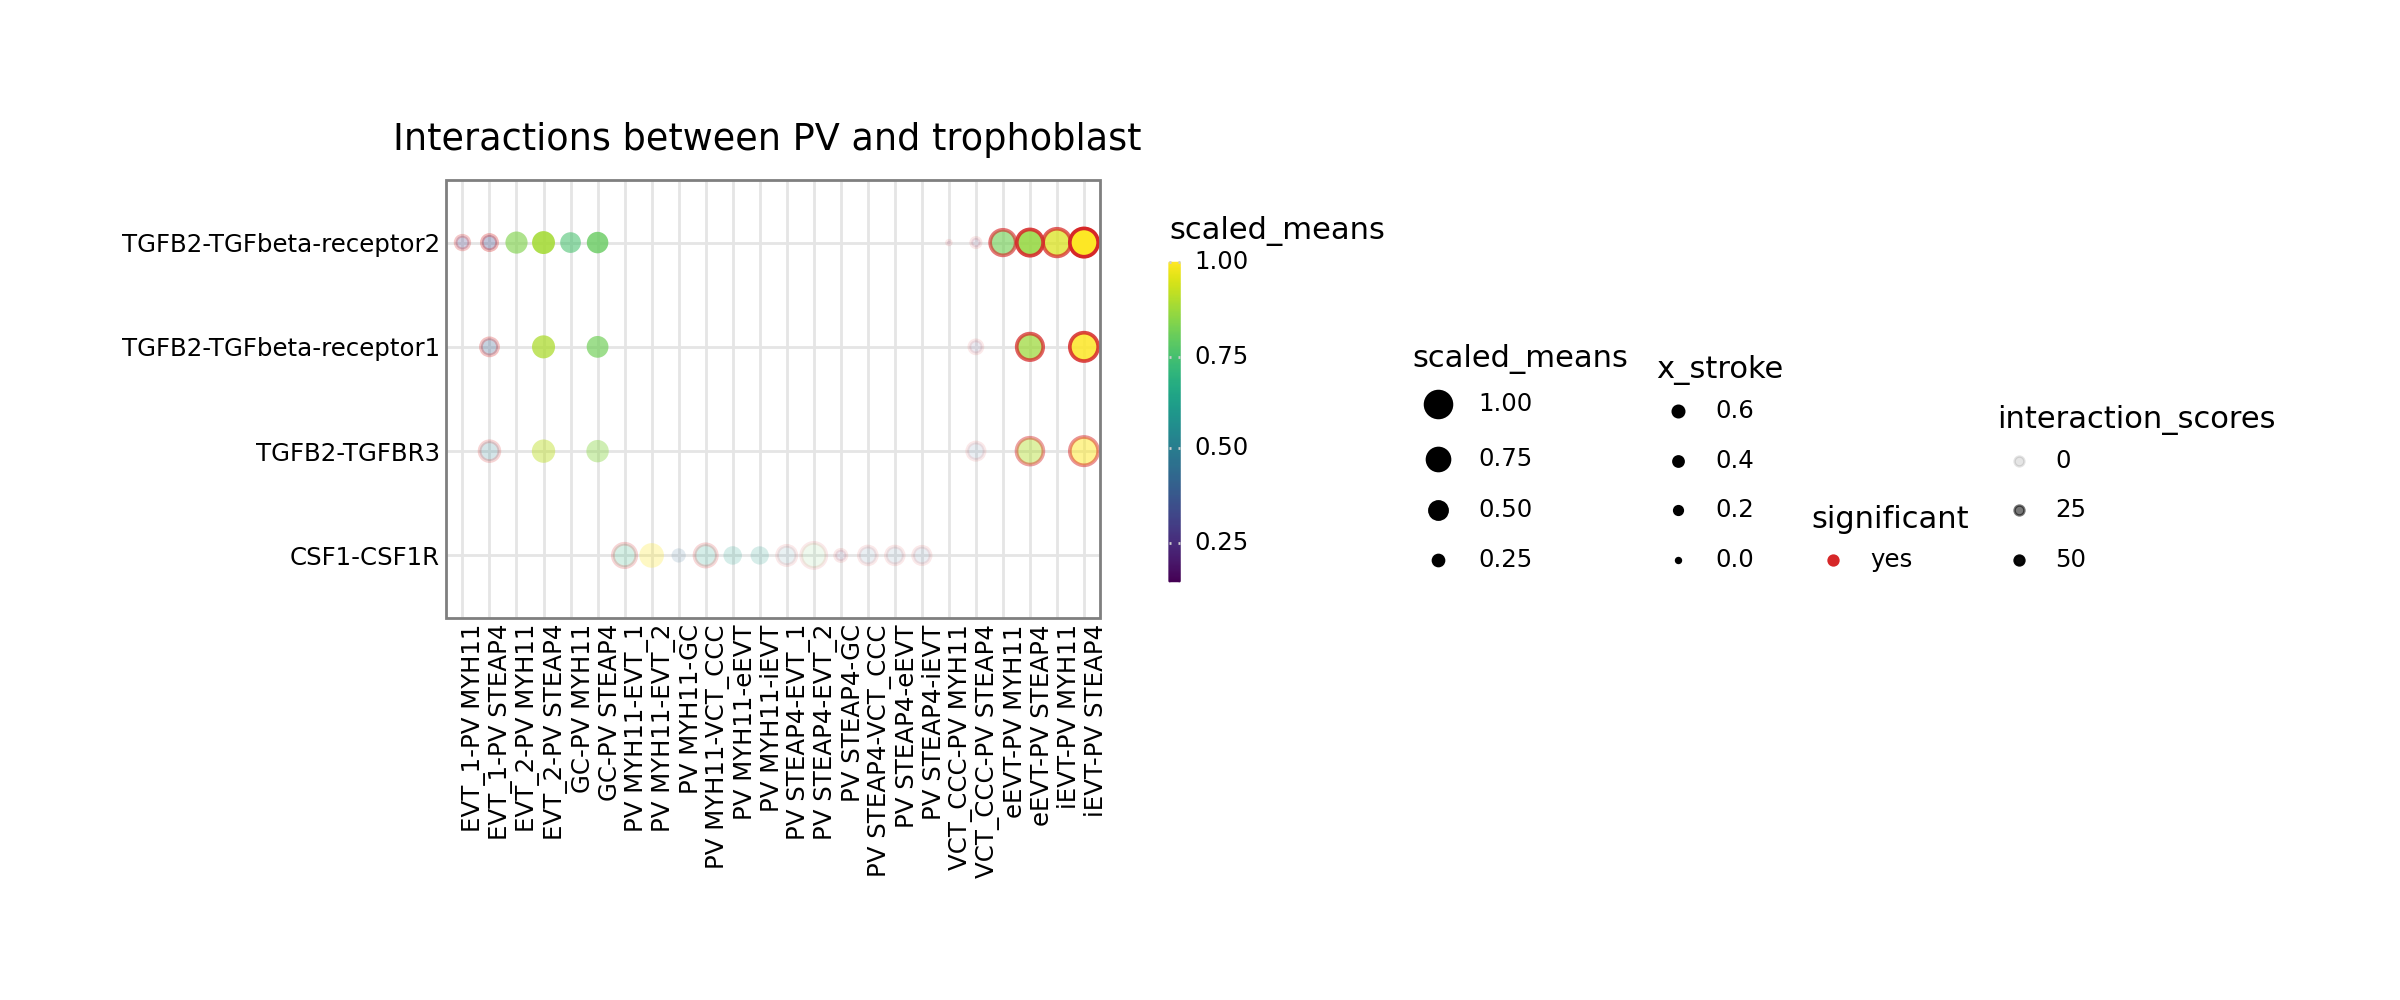

In [50]:
kpy.plot_cpdb(
    adata = adata,
    cell_type1 = "PV MYH11|PV STEAP4|PV MMPP11",
    cell_type2 = "EVT_1|EVT_2|GC|iEVT|eEVT|VCT_CCC", 
    means = cpdb_results['means'],
    pvals = cpdb_results['relevant_interactions'],
    celltype_key = "cell_labels",
    genes = ["TGFB2", "CSF1R"],
    figsize = (11,4),
    title = "Interactions between PV and trophoblast ",
    max_size = 5,
    highlight_size = 0.75,
    degs_analysis = True,
    standard_scale = True,
    interaction_scores = cpdb_results['interaction_scores'],
    scale_alpha_by_interaction_scores=True,
)

/home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages/ktplotspy/plot/plot_cpdb.py:195: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


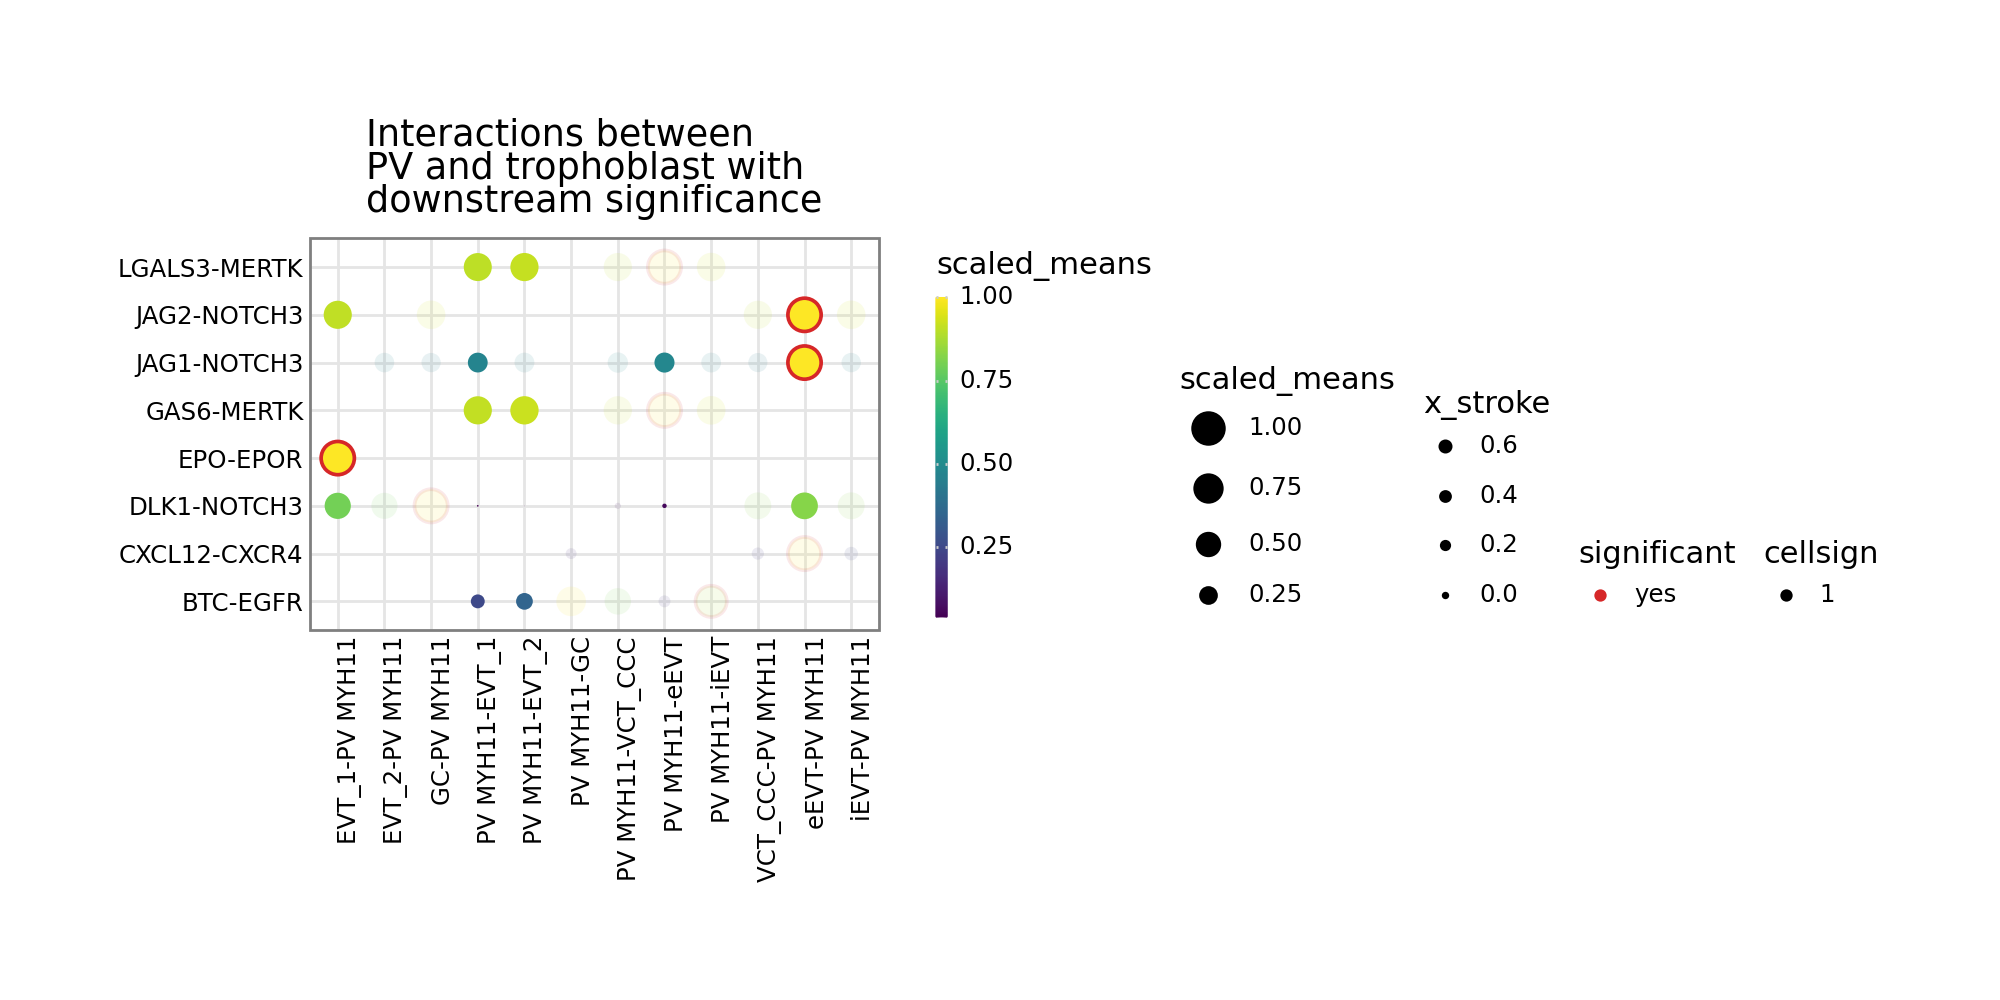

In [51]:
kpy.plot_cpdb(
    adata = adata,
    cell_type1 = "PV MYH11",
    cell_type2 = "EVT_1|EVT_2|GC|iEVT|eEVT|VCT_CCC",
    means = cpdb_results['means'],
    pvals = cpdb_results['relevant_interactions'],
    celltype_key = "cell_labels",
    figsize = (9, 4),
    title = "Interactions between\nPV and trophoblast with\ndownstream significance",
    max_size = 6,
    highlight_size = 0.75,
    degs_analysis = True,
    standard_scale = True,
    cellsign = cpdb_results['CellSign_active_interactions'],
    filter_by_cellsign = True,
    scale_alpha_by_cellsign = True
)

# cellsign = cpdb_results['CellSign_active_interactions'],

# it passes the CellSign table, which flags (per interaction, per cell pair) whether the transcription factor downstream 
# of the receptor is annotated as active in that receptor-expressing cell type. 

# it is is CellphoneDB's answer to "does this receptor-ligand pair actually translate into a transcriptional response, 
# not just co-expression?"

/home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages/ktplotspy/plot/plot_cpdb.py:195: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


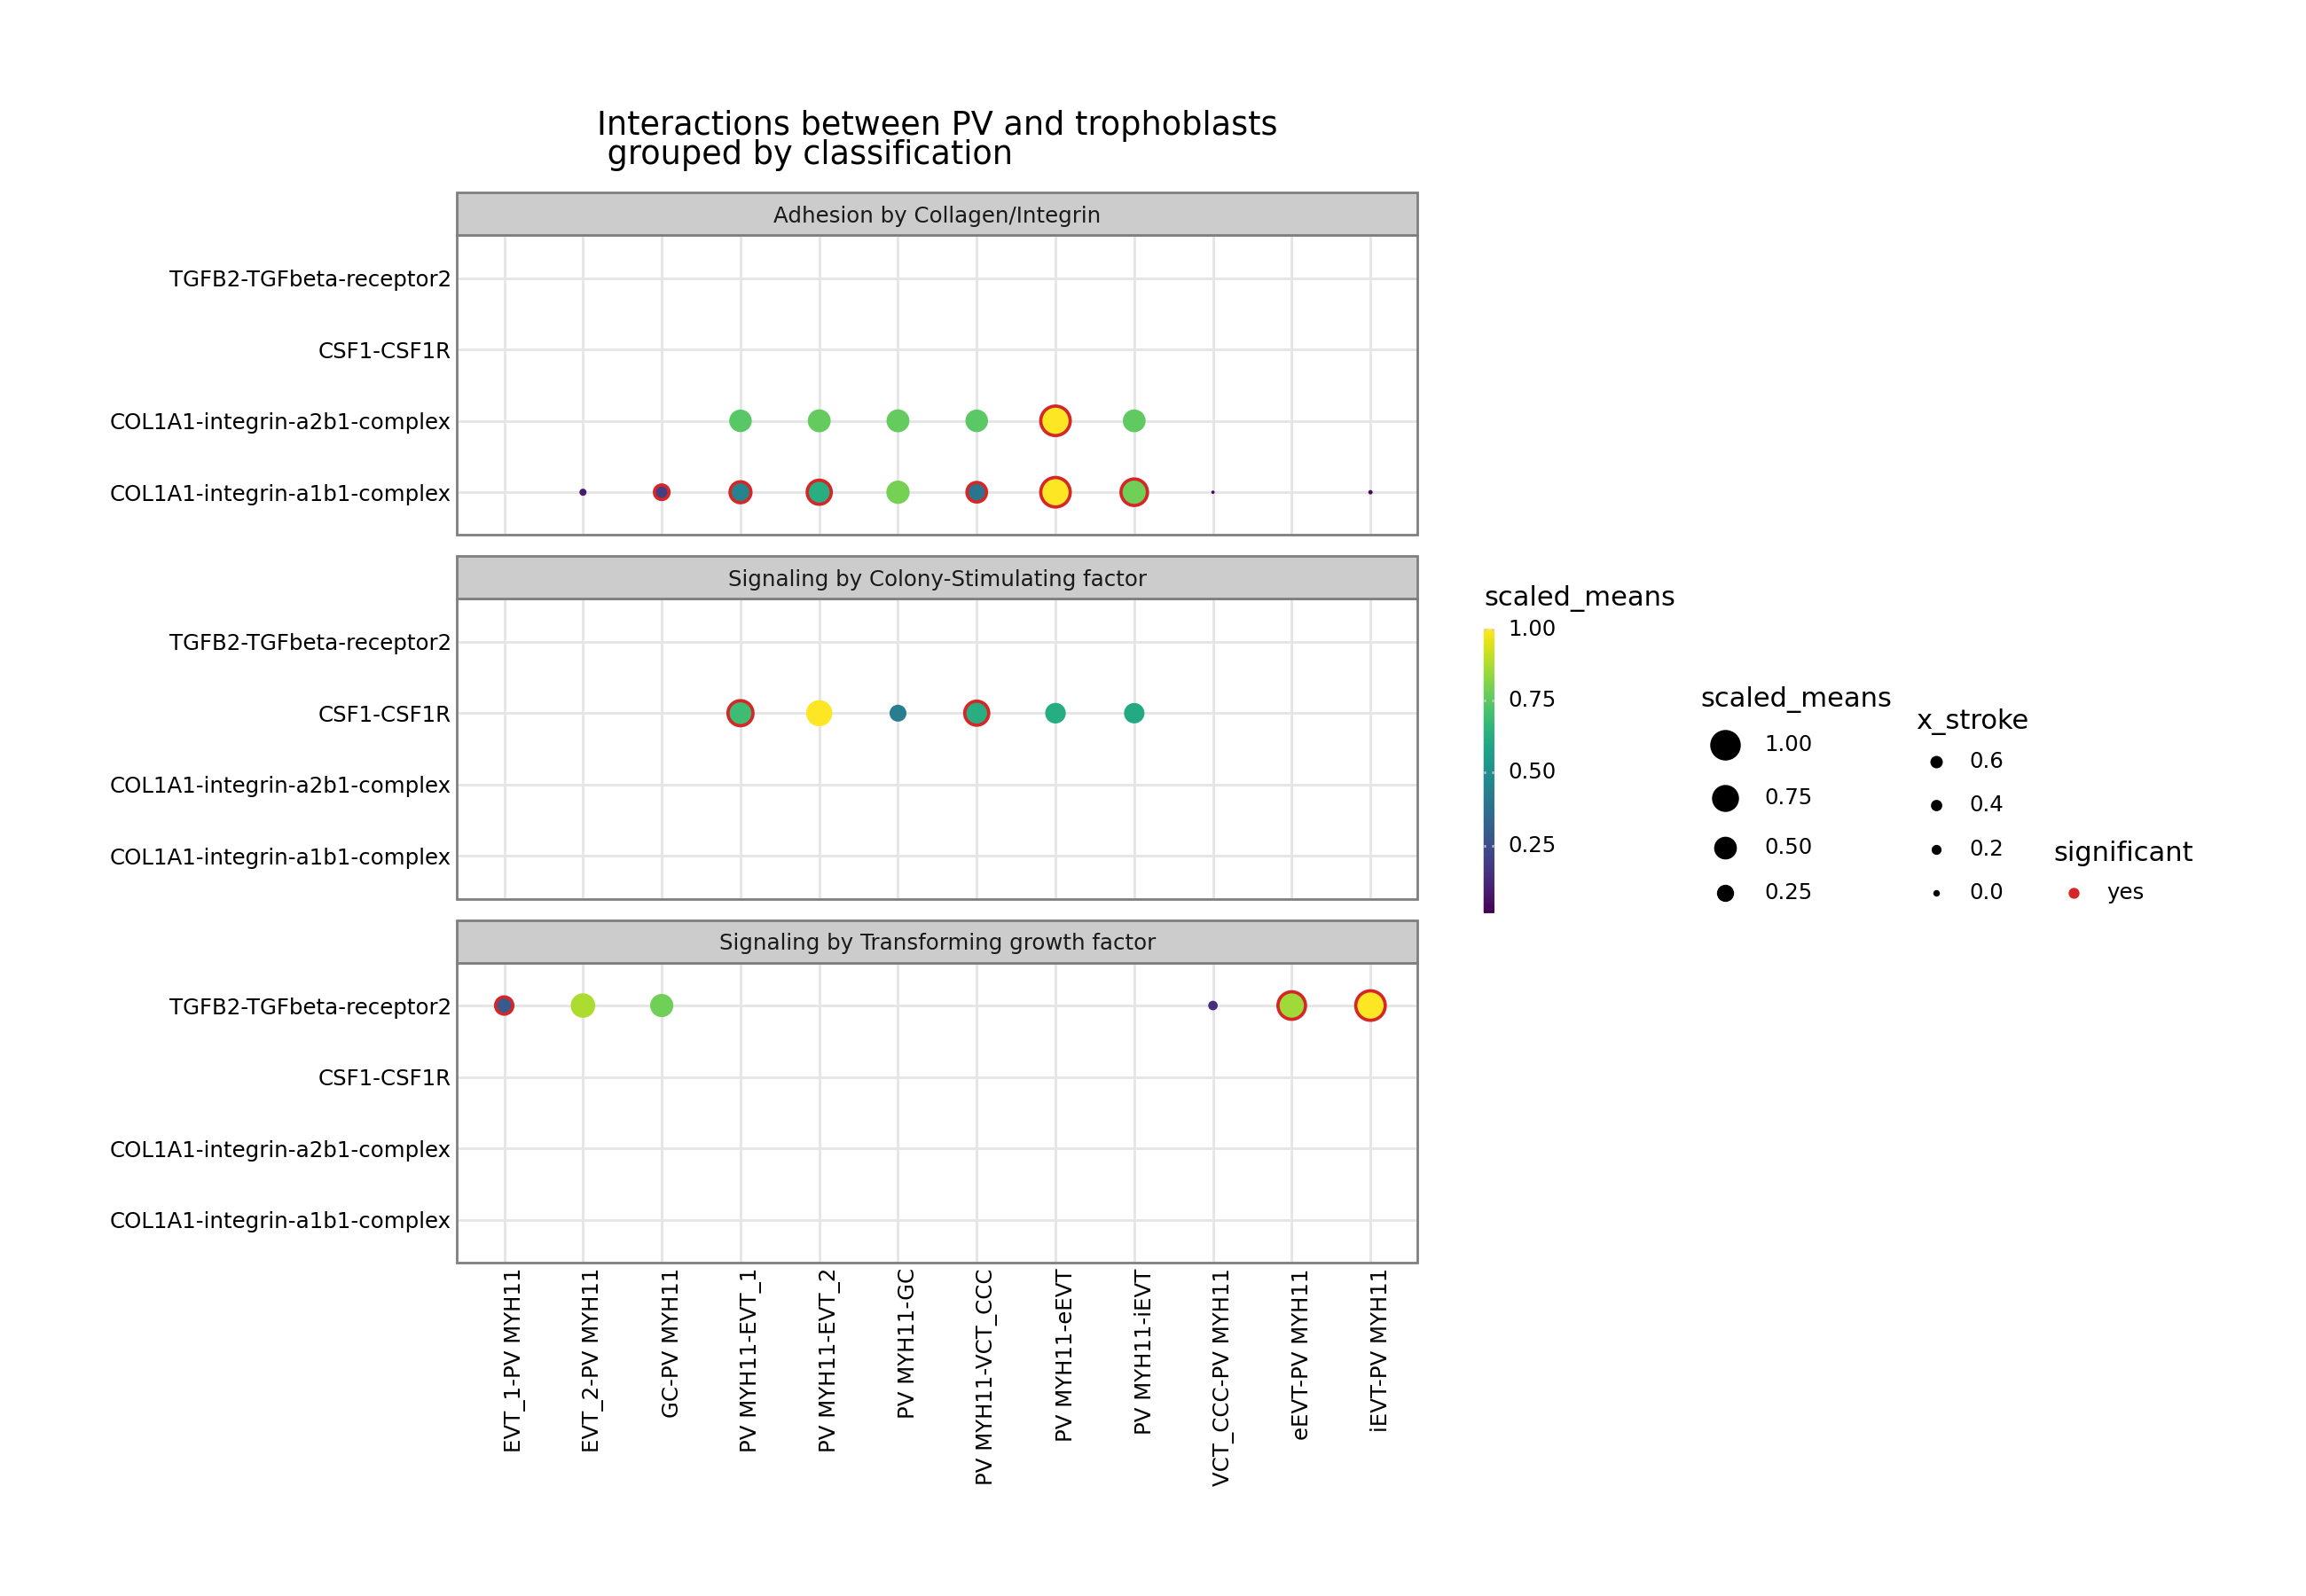

In [52]:
from plotnine import facet_wrap

p = kpy.plot_cpdb(
    adata = adata,
    cell_type1 = "PV MYH11",
    cell_type2 = "EVT_1|EVT_2|GC|iEVT|eEVT|VCT_CCC",
    means = cpdb_results['means'],
    pvals = cpdb_results['relevant_interactions'],
    celltype_key = "cell_labels",
    genes = ["TGFB2", "CSF1R", "COL1A1"],
    figsize = (12, 8),
    title = "Interactions between PV and trophoblasts\n grouped by classification",
    max_size = 6,
    highlight_size = 0.75,
    degs_analysis = True,
    standard_scale = True)

p + facet_wrap("~ classification", ncol = 1)

# No interaction_scores or cellsign arguments

# cellsign arguments	Unlike the previous two plots in this notebook, this one doesn't weight dot transparency by score or CellSign — 
# it's a plainer view: 
# just mean expression (size/color) and DEG-relevance (highlight ring), split into panels by pathway.

In [53]:
print("""extending the method to difference NORMAL vs DISEASE""")

extending the method to difference NORMAL vs DISEASE


In [54]:
print("""

The core idea: fold condition into your cluster labels so a single cpdb_degs_analysis_method.call() run 
treats EVT_1_normal and EVT_1_disease as two separate "cell types." 

This solves two problems at once — it gives Method 3 a condition-aware DEG file to work with, 
and (as we discussed with interaction_scores) keeps the 0–10 scaling shared across both conditions in one run, 
so scores stay directly comparable.

""")



The core idea: fold condition into your cluster labels so a single cpdb_degs_analysis_method.call() run 
treats EVT_1_normal and EVT_1_disease as two separate "cell types." 

This solves two problems at once — it gives Method 3 a condition-aware DEG file to work with, 
and (as we discussed with interaction_scores) keeps the 0–10 scaling shared across both conditions in one run, 
so scores stay directly comparable.




In [55]:
print("""

1. Combine cell type + condition in your metadata

metadata['cluster'] = metadata['cell_type'] + '_' + metadata['condition']
# e.g. "EVT_1_disease", "EVT_1_normal", "GC_disease", "GC_normal", ...
metadata[['barcode_sample', 'cluster']].to_csv('data/metadata_by_condition.tsv', sep='\t', index=False)

Your .h5ad/counts_file_path must contain cells from both conditions together (not split into two files) — 
Method 3 needs one combined run here, unlike the "run separately and diff the outputs" fallback we discussed for Method 2.

""")




1. Combine cell type + condition in your metadata

metadata['cluster'] = metadata['cell_type'] + '_' + metadata['condition']
# e.g. "EVT_1_disease", "EVT_1_normal", "GC_disease", "GC_normal", ...
metadata[['barcode_sample', 'cluster']].to_csv('data/metadata_by_condition.tsv', sep='	', index=False)

Your .h5ad/counts_file_path must contain cells from both conditions together (not split into two files) — 
Method 3 needs one combined run here, unlike the "run separately and diff the outputs" fallback we discussed for Method 2.




In [56]:
print("""

2. Compute condition-vs-condition DEGs, per cell type (not cluster-vs-rest)

import scanpy as sc

degs_rows = []
for ct in adata.obs['cell_type'].unique():
    sub = adata[adata.obs['cell_type'] == ct].copy()
    sc.tl.rank_genes_groups(sub, groupby='condition', groups=['disease'], reference='normal', method='wilcoxon')
    res = sc.get.rank_genes_groups_df(sub, group='disease')
    res = res[(res['pvals_adj'] < 0.05) & (res['logfoldchanges'] > 0.1)]
    res['cluster'] = f'{ct}_disease'
    degs_rows.append(res[['cluster', 'names']].rename(columns={'names': 'gene'}))

degs_df = pd.concat(degs_rows)
degs_df.to_csv('data/DEGs_disease_vs_normal.tsv', sep='\t', index=False)
This is a per-cell-type, disease-vs-normal comparison — the same mechanism the tutorial used (FindAllMarkers-style), 
just with groupby='condition' restricted within each cell type instead of groupby='cell_type' across the whole dataset.

""")




2. Compute condition-vs-condition DEGs, per cell type (not cluster-vs-rest)

import scanpy as sc

degs_rows = []
for ct in adata.obs['cell_type'].unique():
    sub = adata[adata.obs['cell_type'] == ct].copy()
    sc.tl.rank_genes_groups(sub, groupby='condition', groups=['disease'], reference='normal', method='wilcoxon')
    res = sc.get.rank_genes_groups_df(sub, group='disease')
    res = res[(res['pvals_adj'] < 0.05) & (res['logfoldchanges'] > 0.1)]
    res['cluster'] = f'{ct}_disease'
    degs_rows.append(res[['cluster', 'names']].rename(columns={'names': 'gene'}))

degs_df = pd.concat(degs_rows)
degs_df.to_csv('data/DEGs_disease_vs_normal.tsv', sep='	', index=False)
This is a per-cell-type, disease-vs-normal comparison — the same mechanism the tutorial used (FindAllMarkers-style), 
just with groupby='condition' restricted within each cell type instead of groupby='cell_type' across the whole dataset.




In [57]:
print("""

3. Run Method 3 once, on the combined data

from cellphonedb.src.core.methods import cpdb_degs_analysis_method

cpdb_results = cpdb_degs_analysis_method.call(
    cpdb_file_path=cpdb_file_path,
    meta_file_path='data/metadata_by_condition.tsv',   # cluster = celltype_condition
    counts_file_path=counts_file_path,                  # both conditions combined
    degs_file_path='data/DEGs_disease_vs_normal.tsv',
    counts_data='hgnc_symbol',
    microenvs_file_path=microenvs_file_path,            # update this too if you use it — cluster names must match
    score_interactions=True,
    threshold=0.1,
    threads=5,
    output_path='results/method3_disease_vs_normal',
)

""")



3. Run Method 3 once, on the combined data

from cellphonedb.src.core.methods import cpdb_degs_analysis_method

cpdb_results = cpdb_degs_analysis_method.call(
    cpdb_file_path=cpdb_file_path,
    meta_file_path='data/metadata_by_condition.tsv',   # cluster = celltype_condition
    counts_file_path=counts_file_path,                  # both conditions combined
    degs_file_path='data/DEGs_disease_vs_normal.tsv',
    counts_data='hgnc_symbol',
    microenvs_file_path=microenvs_file_path,            # update this too if you use it — cluster names must match
    score_interactions=True,
    threshold=0.1,
    threads=5,
    output_path='results/method3_disease_vs_normal',
)




In [58]:
print("""

4. Read the result directly as a condition comparison
Your output columns are now things like EVT_1_disease|GC_disease and EVT_1_normal|GC_normal side by side in the same table:


means = cpdb_results['means']
means[['interacting_pair', 'EVT_1_disease|GC_disease', 'EVT_1_normal|GC_normal']]

Same for interaction_scores — and because both conditions were scaled together in one run, 
a score of 60 in disease and 40 in normal is now a valid comparison (unlike running two separate calls, 
which we established isn't safe to compare directly).

One thing to double check: if you also use microenvs_file_path or active_tfs_file_path, 
update those files too so their cluster names match the new celltype_condition format — 
otherwise CellphoneDB won't recognize EVT_1_disease as belonging to a microenvironment or having active TFs defined.

""")



4. Read the result directly as a condition comparison
Your output columns are now things like EVT_1_disease|GC_disease and EVT_1_normal|GC_normal side by side in the same table:


means = cpdb_results['means']
means[['interacting_pair', 'EVT_1_disease|GC_disease', 'EVT_1_normal|GC_normal']]

Same for interaction_scores — and because both conditions were scaled together in one run, 
a score of 60 in disease and 40 in normal is now a valid comparison (unlike running two separate calls, 
which we established isn't safe to compare directly).

One thing to double check: if you also use microenvs_file_path or active_tfs_file_path, 
update those files too so their cluster names match the new celltype_condition format — 
otherwise CellphoneDB won't recognize EVT_1_disease as belonging to a microenvironment or having active TFs defined.


